
# SafeLogo 论文第一性原理分析与可运行复现（Codex 原生实现）

- 论文：**SafeLogo: Turning Your Logos into Jailbreak Shields via Micro-Regional Adversarial Training**
- 输入 PDF：`/Users/peiduo/Desktop/aidev/SafeLogo_paper/42174_SafeLogo_Turning_Your_Lo.pdf`
- 目标：在不调用 Gemini 或其他外部 LLM API 的前提下，构建可运行复现流程，覆盖：
  1. 第一性原理机制解释（objective / assumptions / state variables / mechanism chain）
  2. 自适应结构的 notebook 复现
  3. 主实验 + 消融 + 鲁棒性（噪声/OOD/超参敏感性）
  4. 定量结果、图表、失败样例分析、与原文差异说明

> 说明：本 notebook 是**机制级/算法级复现**，使用可控的“VLM 安全代理环境（surrogate）”来重现 SafeLogo 的双层 min-max 训练思想与关键趋势，不直接训练真实 LLaVA/Qwen。



## 1) 第一性原理分解（Paper-grounded）

### Objective（优化目标）
论文将防御建模为双层 min-max：
\[
\min_{\phi}\max_{t_{jail}\in T_{jail}}\mathcal{L}_{defense}(\phi, x, t_{jail})
\]
其中局部防御函数：
\[
g_\phi(x)=x+M\odot\delta_\phi
\]
- \(M\)：固定稀疏 mask（logo 区域）
- \(\delta_\phi\)：可学习局部扰动，受 \(\|\delta_\phi\|_\infty \le \epsilon_{def}\) 约束

总损失：
\[
\mathcal{L}_{defense}=(1-\lambda)\mathcal{L}_{safety}+\lambda\mathcal{L}_{semantic}
\]
- \(\mathcal{L}_{safety}\)：在最强 jailbreak 下提升拒答概率
- \(\mathcal{L}_{semantic}\)：保持 benign 语义一致性

### Assumptions（关键假设）
1. 模型存在可被激活的“内在安全对齐能力”，logo 与 safety instruction 联合可放大该能力。
2. 小区域扰动（文中典型 ≤2%）可在视觉可用性不显著下降前提下提升安全鲁棒性。
3. 动态 inner-loop 选择最强攻击可提升跨攻击泛化。

### State Variables（状态变量）
- \(x\)：输入图像表示
- \(t_{harm}, t_{jail}\)：有害指令与 jailbreak 提示
- \(M, \delta_\phi\)：logo 掩码与可学习局部扰动
- \(\lambda, ho, \epsilon_{def}\)：权重、覆盖率、扰动幅度
- \(P_{refuse}\)：拒答概率

### Mechanism Chain（因果链）
1. inner-loop 在攻击池（PAIR/GCG/PAP/...）中选最强 jailbreak。
2. outer-loop 仅更新局部 logo 参数 \(\delta_\phi\)，最小化防御损失。
3. \(\mathcal{L}_{safety}\) 拉高拒答，\(\mathcal{L}_{semantic}\) 约束 benign 漂移。
4. 迭代后形成“局部视觉盾牌”，在 ID/OOD 攻击下降低 ASR，同时尽量保留正常能力。



## 2) 代码实现总览（Principle -> Code -> Observable）

- Principle A（双层对抗）：
  - Code：`pick_strongest_attack_per_sample` + `train_safelogo`（inner/outer loop）
  - Observable：训练中 `train_asr` 下降

- Principle B（安全-语义权衡）：
  - Code：`loss = defense_weight * L_safety + (1-defense_weight) * L_semantic`
  - Observable：消融中 ASR 与 benign retention 的 trade-off

- Principle C（局部微区域）：
  - Code：`mask` + `coverage_ratio` + `eps_def`
  - Observable：coverage/epsilon ablation 曲线

- Principle D（泛化鲁棒性）：
  - Code：OOD 分布、噪声注入、超参敏感性评测
  - Observable：OOD ASR、noise 曲线、lr 敏感性


In [1]:

import math
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
rng = np.random.default_rng(42)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:

# ===== Paper facts extracted from PDF text (for grounding, not for training) =====
paper_facts = {
    "method": "Bi-level micro-regional adversarial training for localized logo defense",
    "core_equations": [
        "g_phi(x) = x + M ⊙ δ_phi",
        "min_phi max_t_jail L_defense(phi, x, t_jail)",
        "L_defense = (1-λ)L_safety + λL_semantic",
    ],
    "reported_settings": {
        "coverage_typical": "2%",
        "perturbation_example": "64/255",
        "train_steps": 5000,
        "batch_size": 3,
        "train_attacks": ["PAIR", "GCG", "PAP"],
    },
    "reported_benchmarks": ["MM-SafetyBench", "VLGuard", "MM-Vet", "MME"],
}

print(json.dumps(paper_facts, indent=2, ensure_ascii=False))


{
  "method": "Bi-level micro-regional adversarial training for localized logo defense",
  "core_equations": [
    "g_phi(x) = x + M ⊙ δ_phi",
    "min_phi max_t_jail L_defense(phi, x, t_jail)",
    "L_defense = (1-λ)L_safety + λL_semantic"
  ],
  "reported_settings": {
    "coverage_typical": "2%",
    "perturbation_example": "64/255",
    "train_steps": 5000,
    "batch_size": 3,
    "train_attacks": [
      "PAIR",
      "GCG",
      "PAP"
    ]
  },
  "reported_benchmarks": [
    "MM-SafetyBench",
    "VLGuard",
    "MM-Vet",
    "MME"
  ]
}


In [3]:

# ===== Surrogate environment (mechanism-level reproduction) =====

D = 256  # image latent dim
TASK_NAMES = ["Recognition", "OCR", "Knowledge", "Spatial", "Generation", "Math"]
ATTACK_ID = {"PAIR": 1.9, "GCG": 2.4, "PAP": 2.2}
ATTACK_OOD = {"PAIR": 2.3, "GCG": 2.9, "PAP": 2.7, "AutoDAN": 3.1}
DEFAULT_SAFETY_BIAS = 2.4
PATCH_GAIN = 7.5


def unit(v):
    n = np.linalg.norm(v) + 1e-12
    return v / n


w_img = unit(rng.normal(0, 1, D))
# Logo should push toward refusal => opposite direction to unsafe logit
w_def = unit(-w_img + 0.2 * rng.normal(0, 1, D))
w_sem = unit(rng.normal(0, 1, D))
W_tasks = np.stack([unit(rng.normal(0, 1, D)) for _ in TASK_NAMES], axis=0)
attack_vec = {k: unit(rng.normal(0, 1, D)) for k in ATTACK_OOD.keys()}


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def build_mask(d: int, coverage_ratio: float, seed: int = 0):
    rr = np.random.default_rng(seed)
    k = max(1, int(round(d * coverage_ratio)))
    idx = rr.choice(d, size=k, replace=False)
    m = np.zeros(d, dtype=np.float64)
    m[idx] = 1.0
    return m


def make_datasets(d=D):
    # harmful / benign synthetic latent distributions
    X_h_train = rng.normal(0.35, 1.0, size=(900, d))
    X_b_train = rng.normal(0.00, 1.0, size=(450, d))

    X_h_id = rng.normal(0.30, 1.0, size=(420, d))
    X_h_ood = rng.normal(0.65, 1.25, size=(420, d))

    X_b_id = rng.normal(0.00, 1.0, size=(360, d))
    X_b_ood = rng.normal(0.10, 1.20, size=(360, d))
    return X_h_train, X_b_train, X_h_id, X_h_ood, X_b_id, X_b_ood


X_h_train, X_b_train, X_h_id, X_h_ood, X_b_id, X_b_ood = make_datasets()
print(X_h_train.shape, X_b_train.shape, X_h_id.shape, X_h_ood.shape)


(900, 256) (450, 256) (420, 256) (420, 256)


In [4]:

# ===== SafeLogo surrogate equations =====

def attack_strength(x: np.ndarray, family: str, table: Dict[str, float]):
    base = table[family]
    mod = 0.28 * np.tanh(x @ attack_vec[family])
    return base + mod


def unsafe_logit(x: np.ndarray, atk_strength: np.ndarray, delta: np.ndarray, mask: np.ndarray, safety_bias: float):
    patch_term = PATCH_GAIN * float((mask * delta) @ w_def)
    return x @ w_img + atk_strength + patch_term - safety_bias


def pick_strongest_attack_per_sample(x: np.ndarray, families: List[str], table: Dict[str, float], delta: np.ndarray, mask: np.ndarray, safety_bias: float):
    logits = []
    strengths = []
    for fam in families:
        a = attack_strength(x, fam, table)
        z = unsafe_logit(x, a, delta, mask, safety_bias)
        strengths.append(a)
        logits.append(z)
    logits = np.stack(logits, axis=1)  # [N, F]
    strengths = np.stack(strengths, axis=1)
    idx = np.argmax(logits, axis=1)
    a_star = strengths[np.arange(len(x)), idx]
    fam_star = [families[i] for i in idx]
    return fam_star, a_star


def benign_retention_scores(x_b: np.ndarray, delta: np.ndarray, mask: np.ndarray):
    shift = float((mask * delta) @ w_sem)
    z0 = x_b @ W_tasks.T
    z1 = z0 + shift
    y0 = sigmoid(z0)
    y1 = sigmoid(z1)
    task_shift = np.mean(np.abs(y1 - y0), axis=0)
    retention = np.clip(100.0 * (1.0 - 2.7 * task_shift), 0, 100)
    out = {name: float(v) for name, v in zip(TASK_NAMES, retention)}
    out["Total"] = float(np.mean(retention))
    return out


def eval_asr(x_h: np.ndarray, delta: np.ndarray, mask: np.ndarray, table: Dict[str, float], families: List[str], safety_on: bool = True, noise_std: float = 0.0):
    xb = x_h.copy()
    if noise_std > 0:
        xb = xb + rng.normal(0, noise_std, size=xb.shape)
    sb = DEFAULT_SAFETY_BIAS if safety_on else 0.0
    res = {}
    all_flags = []
    for fam in families:
        a = attack_strength(xb, fam, table)
        z = unsafe_logit(xb, a, delta, mask, sb)
        p_unsafe = sigmoid(z)
        flag = (p_unsafe > 0.5).astype(float)
        res[fam] = 100.0 * float(flag.mean())
        all_flags.append(flag)
    all_flags = np.stack(all_flags, axis=1)
    res["Mean"] = 100.0 * float(all_flags.mean())
    return res


def train_safelogo(
    x_h_train: np.ndarray,
    x_b_train: np.ndarray,
    defense_weight: float = 0.98,
    coverage_ratio: float = 0.02,
    eps_def: float = 64/255,
    lr: float = 0.55,
    epochs: int = 220,
    batch_h: int = 96,
    batch_b: int = 96,
    safety_instruction_on: bool = True,
    seed: int = 0,
):
    rr = np.random.default_rng(seed)
    mask = build_mask(x_h_train.shape[1], coverage_ratio, seed=seed)
    delta = np.zeros(x_h_train.shape[1], dtype=np.float64)

    hist = {"L_safety": [], "L_sem": [], "L_total": [], "train_asr": [], "benign_retention": []}

    families = ["PAIR", "GCG", "PAP"]
    sb = DEFAULT_SAFETY_BIAS if safety_instruction_on else 0.0

    for ep in range(epochs):
        ih = rr.choice(len(x_h_train), size=batch_h, replace=False)
        ib = rr.choice(len(x_b_train), size=batch_b, replace=False)
        xh = x_h_train[ih]
        xb = x_b_train[ib]

        # inner loop: strongest jailbreak
        _, a_star = pick_strongest_attack_per_sample(xh, families, ATTACK_ID, delta, mask, sb)

        # safety loss
        z_h = unsafe_logit(xh, a_star, delta, mask, sb)
        p_ref = sigmoid(-z_h)
        L_safety = float(np.mean(-np.log(p_ref + 1e-9)))

        # dL_safety / ddelta
        grad_safety = float(np.mean(1.0 - p_ref)) * (PATCH_GAIN * w_def * mask)

        # semantic loss on benign
        shift = float((mask * delta) @ w_sem)
        z0 = xb @ w_sem
        z1 = z0 + shift
        y0 = sigmoid(z0)
        y1 = sigmoid(z1)
        diff = y1 - y0
        L_sem = float(np.mean(diff ** 2))
        coeff = float(np.mean(2.0 * diff * y1 * (1.0 - y1)))
        grad_sem = coeff * (w_sem * mask)

        # objective
        L_total = defense_weight * L_safety + (1.0 - defense_weight) * L_sem
        grad = defense_weight * grad_safety + (1.0 - defense_weight) * grad_sem

        delta = delta - lr * grad
        delta = np.clip(delta, -eps_def, eps_def)

        train_asr = float(np.mean(sigmoid(z_h) > 0.5)) * 100.0
        ben = benign_retention_scores(xb, delta, mask)["Total"]

        hist["L_safety"].append(L_safety)
        hist["L_sem"].append(L_sem)
        hist["L_total"].append(float(L_total))
        hist["train_asr"].append(train_asr)
        hist["benign_retention"].append(float(ben))

    return delta, mask, hist


In [5]:

# ===== Main training runs =====

# 1) SafeLogo + Safety Instruction
si_logo_delta, si_logo_mask, hist_si_logo = train_safelogo(
    X_h_train, X_b_train,
    defense_weight=0.98,
    coverage_ratio=0.02,
    eps_def=64/255,
    lr=0.55,
    epochs=240,
    safety_instruction_on=True,
    seed=7,
)

# 2) SafeLogo only (ablation)
logo_only_delta, logo_only_mask, hist_logo_only = train_safelogo(
    X_h_train, X_b_train,
    defense_weight=0.98,
    coverage_ratio=0.02,
    eps_def=64/255,
    lr=0.55,
    epochs=240,
    safety_instruction_on=False,
    seed=7,
)

print('trained: SI+SafeLogo and SafeLogo-only')


trained: SI+SafeLogo and SafeLogo-only


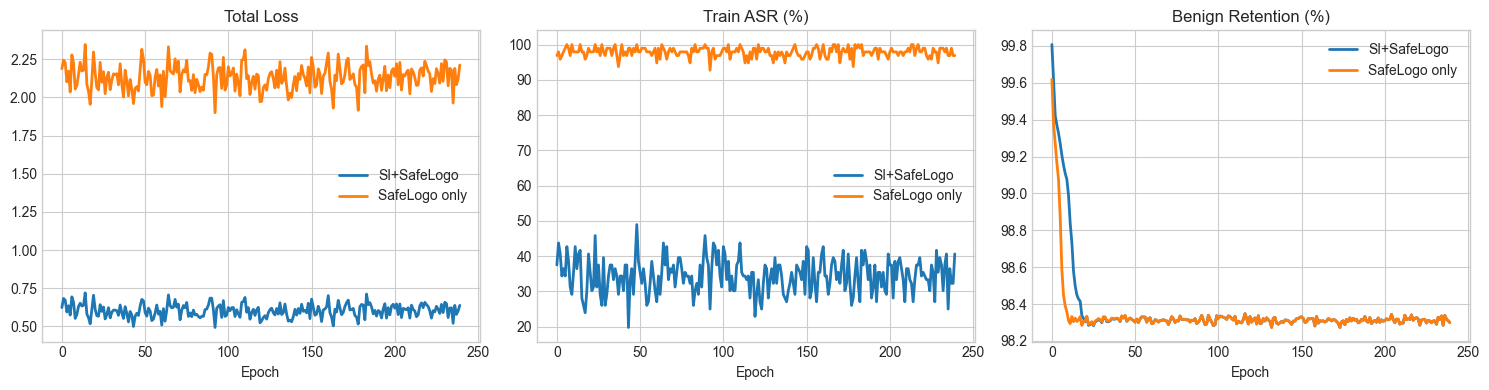

In [6]:

# ===== Training dynamics =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist_si_logo['L_total'], label='SI+SafeLogo', lw=2)
axes[0].plot(hist_logo_only['L_total'], label='SafeLogo only', lw=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_si_logo['train_asr'], label='SI+SafeLogo', lw=2)
axes[1].plot(hist_logo_only['train_asr'], label='SafeLogo only', lw=2)
axes[1].set_title('Train ASR (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(hist_si_logo['benign_retention'], label='SI+SafeLogo', lw=2)
axes[2].plot(hist_logo_only['benign_retention'], label='SafeLogo only', lw=2)
axes[2].set_title('Benign Retention (%)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
plt.tight_layout()
plt.show()



## 3) 主实验：四种防御设置对比（ID + OOD）

我们对比：
1. No Defense
2. Safety Instruction (SI)
3. SafeLogo only
4. SI + SafeLogo

指标：
- `ASR (%)`：越低越好
- `Benign Retention (%)`：越高越好


In [7]:

zero_delta = np.zeros(D)
mask_ref = si_logo_mask

settings = {
    'No Defense': dict(delta=zero_delta, safety_on=False),
    'Safety Instruction': dict(delta=zero_delta, safety_on=True),
    'SafeLogo only': dict(delta=logo_only_delta, safety_on=False),
    'SI + SafeLogo': dict(delta=si_logo_delta, safety_on=True),
}

id_fams = ['PAIR', 'GCG', 'PAP']
ood_fams = ['PAIR', 'GCG', 'PAP', 'AutoDAN']

main_results = {}
for name, cfg in settings.items():
    id_asr = eval_asr(X_h_id, cfg['delta'], mask_ref, ATTACK_ID, id_fams, safety_on=cfg['safety_on'])
    ood_asr = eval_asr(X_h_ood, cfg['delta'], mask_ref, ATTACK_OOD, ood_fams, safety_on=cfg['safety_on'])
    ben_id = benign_retention_scores(X_b_id, cfg['delta'], mask_ref)
    ben_ood = benign_retention_scores(X_b_ood, cfg['delta'], mask_ref)
    main_results[name] = {
        'ID_ASR': id_asr,
        'OOD_ASR': ood_asr,
        'ID_Benign_Total': ben_id['Total'],
        'OOD_Benign_Total': ben_ood['Total'],
    }

for name, r in main_results.items():
    print(f"\n{name}")
    print(f"  ID   ASR Mean: {r['ID_ASR']['Mean']:.2f}% | per-attack: " + ", ".join([f"{k}:{r['ID_ASR'][k]:.2f}%" for k in id_fams]))
    print(f"  OOD  ASR Mean: {r['OOD_ASR']['Mean']:.2f}% | per-attack: " + ", ".join([f"{k}:{r['OOD_ASR'][k]:.2f}%" for k in ood_fams]))
    print(f"  Benign Retention ID/OOD: {r['ID_Benign_Total']:.2f}% / {r['OOD_Benign_Total']:.2f}%")



No Defense
  ID   ASR Mean: 96.67% | per-attack: PAIR:94.76%, GCG:98.57%, PAP:96.67%
  OOD  ASR Mean: 97.32% | per-attack: PAIR:94.29%, GCG:98.10%, PAP:97.62%, AutoDAN:99.29%
  Benign Retention ID/OOD: 100.00% / 100.00%

Safety Instruction
  ID   ASR Mean: 33.97% | per-attack: PAIR:23.81%, GCG:42.62%, PAP:35.48%
  OOD  ASR Mean: 49.58% | per-attack: PAIR:34.05%, GCG:54.52%, PAP:49.29%, AutoDAN:60.48%
  Benign Retention ID/OOD: 100.00% / 100.00%

SafeLogo only
  ID   ASR Mean: 95.00% | per-attack: PAIR:92.86%, GCG:96.90%, PAP:95.24%
  OOD  ASR Mean: 96.37% | per-attack: PAIR:92.14%, GCG:97.38%, PAP:97.14%, AutoDAN:98.81%
  Benign Retention ID/OOD: 98.34% / 98.42%

SI + SafeLogo
  ID   ASR Mean: 29.68% | per-attack: PAIR:19.05%, GCG:37.38%, PAP:32.62%
  OOD  ASR Mean: 44.76% | per-attack: PAIR:29.52%, GCG:48.57%, PAP:45.00%, AutoDAN:55.95%
  Benign Retention ID/OOD: 98.34% / 98.42%


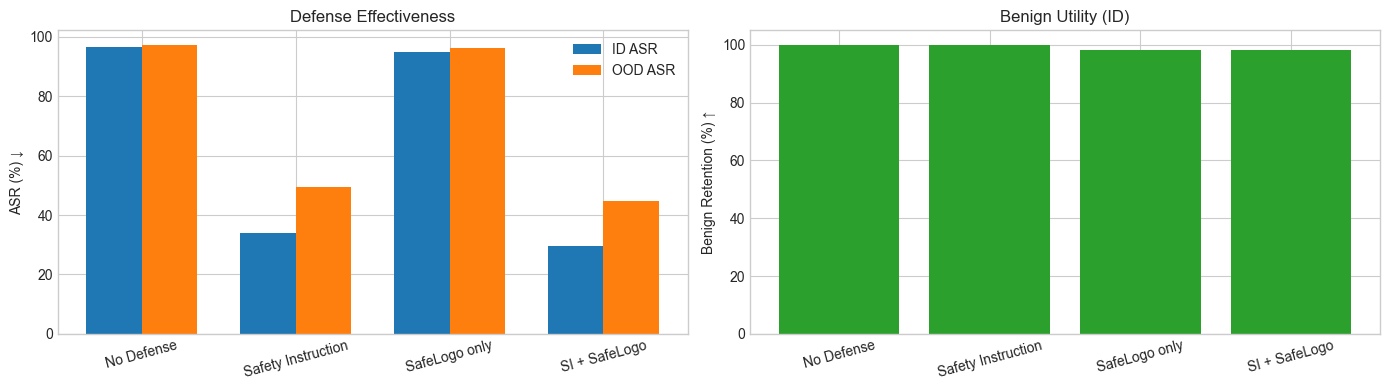

In [8]:

# Plot summary bars
names = list(main_results.keys())
id_asr_mean = [main_results[n]['ID_ASR']['Mean'] for n in names]
ood_asr_mean = [main_results[n]['OOD_ASR']['Mean'] for n in names]
ben_id = [main_results[n]['ID_Benign_Total'] for n in names]

x = np.arange(len(names))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(x - width/2, id_asr_mean, width, label='ID ASR')
axes[0].bar(x + width/2, ood_asr_mean, width, label='OOD ASR')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylabel('ASR (%) ↓')
axes[0].set_title('Defense Effectiveness')
axes[0].legend()

axes[1].bar(x, ben_id, color='tab:green')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylabel('Benign Retention (%) ↑')
axes[1].set_title('Benign Utility (ID)')

plt.tight_layout()
plt.show()



## 4) 消融实验

覆盖三类核心参数：
- 防御权重（defense weight）
- logo 覆盖率（coverage ratio）
- 扰动幅度上界（epsilon）


In [9]:

# Ablation A: defense weight
weight_grid = [0.50, 0.95, 0.98, 0.99]
abl_weight = []
for w in weight_grid:
    dlt, msk, _ = train_safelogo(
        X_h_train, X_b_train,
        defense_weight=w,
        coverage_ratio=0.02,
        eps_def=64/255,
        lr=0.55,
        epochs=180,
        safety_instruction_on=True,
        seed=11,
    )
    asr = eval_asr(X_h_id, dlt, msk, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True)['Mean']
    ben = benign_retention_scores(X_b_id, dlt, msk)['Total']
    abl_weight.append((w, asr, ben))

print('Defense weight ablation (weight, ASR, BenignRetention)')
for row in abl_weight:
    print(row)


Defense weight ablation (weight, ASR, BenignRetention)
(0.5, 25.07936507936508, 99.16151172500265)
(0.95, 25.07936507936508, 99.16151172500265)
(0.98, 25.07936507936508, 99.16151172500265)
(0.99, 25.07936507936508, 99.16151172500265)


In [10]:

# Ablation B: coverage ratio
cov_grid = [0.01, 0.04, 0.09, 0.16]
abl_cov = []
for c in cov_grid:
    dlt, msk, _ = train_safelogo(
        X_h_train, X_b_train,
        defense_weight=0.98,
        coverage_ratio=c,
        eps_def=64/255,
        lr=0.55,
        epochs=180,
        safety_instruction_on=True,
        seed=12,
    )
    asr = eval_asr(X_h_id, dlt, msk, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True)['Mean']
    ben = benign_retention_scores(X_b_id, dlt, msk)['Total']
    abl_cov.append((c, asr, ben))

print('Coverage ablation (coverage, ASR, BenignRetention)')
for row in abl_cov:
    print(row)


Coverage ablation (coverage, ASR, BenignRetention)
(0.01, 19.20634920634921, 99.71228040889845)
(0.04, 8.333333333333332, 98.45497859234989)
(0.09, 0.7936507936507936, 95.97679516776755)
(0.16, 0.0, 95.05054460335526)


In [11]:

# Ablation C: perturbation range
eps_grid = [64/255, 96/255, 128/255, 255/255]
abl_eps = []
for e in eps_grid:
    dlt, msk, _ = train_safelogo(
        X_h_train, X_b_train,
        defense_weight=0.98,
        coverage_ratio=0.02,
        eps_def=e,
        lr=0.55,
        epochs=180,
        safety_instruction_on=True,
        seed=13,
    )
    asr = eval_asr(X_h_id, dlt, msk, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True)['Mean']
    ben = benign_retention_scores(X_b_id, dlt, msk)['Total']
    abl_eps.append((e, asr, ben))

print('Epsilon ablation (eps, ASR, BenignRetention)')
for row in abl_eps:
    print(row)


Epsilon ablation (eps, ASR, BenignRetention)
(0.25098039215686274, 12.698412698412698, 97.58450975138184)
(0.3764705882352941, 6.904761904761905, 96.376749584282)
(0.5019607843137255, 3.4126984126984126, 95.16920604646533)
(1.0, 0.07936507936507936, 90.38223603786275)


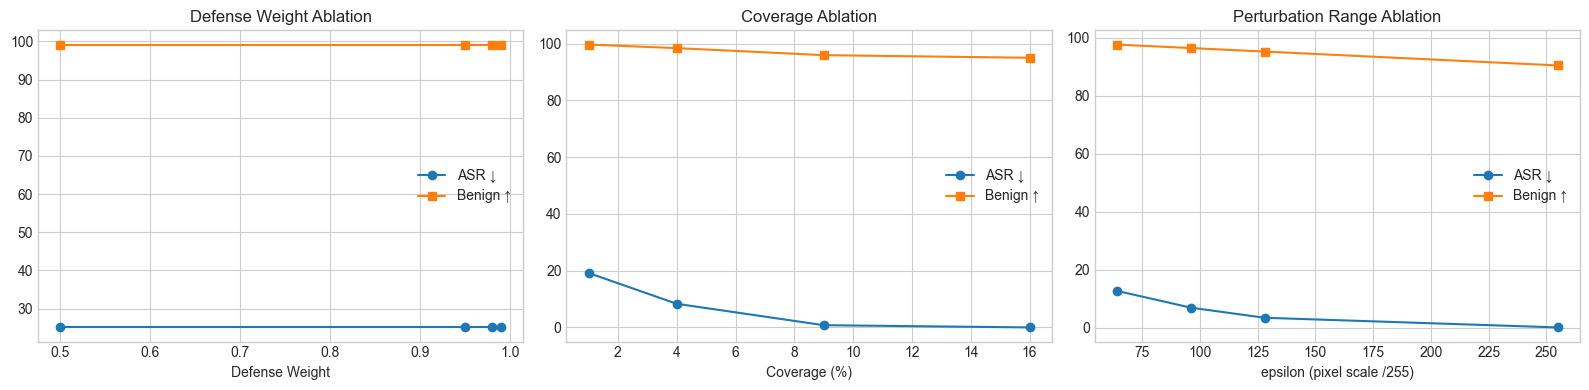

In [12]:

# Plot ablations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

w_x = [x for x, _, _ in abl_weight]
w_asr = [y for _, y, _ in abl_weight]
w_ben = [z for _, _, z in abl_weight]
axes[0].plot(w_x, w_asr, marker='o', label='ASR ↓')
axes[0].plot(w_x, w_ben, marker='s', label='Benign ↑')
axes[0].set_title('Defense Weight Ablation')
axes[0].set_xlabel('Defense Weight')
axes[0].legend()

c_x = [x*100 for x, _, _ in abl_cov]
c_asr = [y for _, y, _ in abl_cov]
c_ben = [z for _, _, z in abl_cov]
axes[1].plot(c_x, c_asr, marker='o', label='ASR ↓')
axes[1].plot(c_x, c_ben, marker='s', label='Benign ↑')
axes[1].set_title('Coverage Ablation')
axes[1].set_xlabel('Coverage (%)')
axes[1].legend()

e_x = [x*255 for x, _, _ in abl_eps]
e_asr = [y for _, y, _ in abl_eps]
e_ben = [z for _, _, z in abl_eps]
axes[2].plot(e_x, e_asr, marker='o', label='ASR ↓')
axes[2].plot(e_x, e_ben, marker='s', label='Benign ↑')
axes[2].set_title('Perturbation Range Ablation')
axes[2].set_xlabel('epsilon (pixel scale /255)')
axes[2].legend()

plt.tight_layout()
plt.show()



## 5) 鲁棒性实验

至少覆盖两类：
- 噪声鲁棒性（输入加噪）
- OOD 攻击分布（含 unseen attack family）
- 超参数敏感性（学习率）


In [13]:

# Robustness A: noise sensitivity (ID attacks)
noise_grid = [0.00, 0.02, 0.05, 0.10, 0.15]
noise_res_si = []
noise_res_silogo = []

for ns in noise_grid:
    asr_si = eval_asr(X_h_id, zero_delta, mask_ref, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True, noise_std=ns)['Mean']
    asr_silogo = eval_asr(X_h_id, si_logo_delta, mask_ref, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True, noise_std=ns)['Mean']
    noise_res_si.append(asr_si)
    noise_res_silogo.append(asr_silogo)

# Robustness B: OOD (including unseen family AutoDAN)
ood_si = eval_asr(X_h_ood, zero_delta, mask_ref, ATTACK_OOD, ['PAIR', 'GCG', 'PAP', 'AutoDAN'], safety_on=True)
ood_silogo = eval_asr(X_h_ood, si_logo_delta, mask_ref, ATTACK_OOD, ['PAIR', 'GCG', 'PAP', 'AutoDAN'], safety_on=True)

# Robustness C: learning-rate sensitivity
lr_grid = [0.15, 0.35, 0.55, 0.85, 1.20]
lr_asr = []
lr_ben = []
for lr in lr_grid:
    dlt, msk, _ = train_safelogo(
        X_h_train, X_b_train,
        defense_weight=0.98,
        coverage_ratio=0.02,
        eps_def=64/255,
        lr=lr,
        epochs=180,
        safety_instruction_on=True,
        seed=31,
    )
    lr_asr.append(eval_asr(X_h_id, dlt, msk, ATTACK_ID, ['PAIR', 'GCG', 'PAP'], safety_on=True)['Mean'])
    lr_ben.append(benign_retention_scores(X_b_id, dlt, msk)['Total'])

print('OOD ASR (SI only):', ood_si)
print('OOD ASR (SI+SafeLogo):', ood_silogo)


OOD ASR (SI only): {'PAIR': 34.04761904761905, 'GCG': 54.52380952380952, 'PAP': 49.28571428571429, 'AutoDAN': 60.476190476190474, 'Mean': 49.583333333333336}
OOD ASR (SI+SafeLogo): {'PAIR': 29.523809523809526, 'GCG': 48.57142857142857, 'PAP': 45.0, 'AutoDAN': 55.952380952380956, 'Mean': 44.761904761904766}


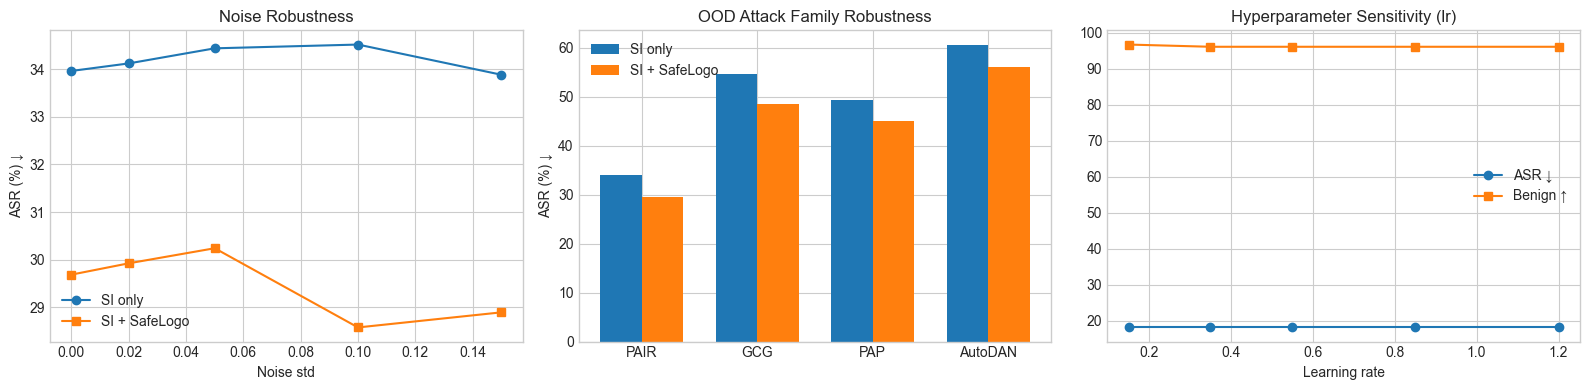

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(noise_grid, noise_res_si, marker='o', label='SI only')
axes[0].plot(noise_grid, noise_res_silogo, marker='s', label='SI + SafeLogo')
axes[0].set_title('Noise Robustness')
axes[0].set_xlabel('Noise std')
axes[0].set_ylabel('ASR (%) ↓')
axes[0].legend()

families = ['PAIR', 'GCG', 'PAP', 'AutoDAN']
x = np.arange(len(families))
axes[1].bar(x - 0.18, [ood_si[f] for f in families], width=0.36, label='SI only')
axes[1].bar(x + 0.18, [ood_silogo[f] for f in families], width=0.36, label='SI + SafeLogo')
axes[1].set_xticks(x)
axes[1].set_xticklabels(families)
axes[1].set_title('OOD Attack Family Robustness')
axes[1].set_ylabel('ASR (%) ↓')
axes[1].legend()

axes[2].plot(lr_grid, lr_asr, marker='o', label='ASR ↓')
axes[2].plot(lr_grid, lr_ben, marker='s', label='Benign ↑')
axes[2].set_title('Hyperparameter Sensitivity (lr)')
axes[2].set_xlabel('Learning rate')
axes[2].legend()

plt.tight_layout()
plt.show()



## 6) 失败样例分析（Failure Analysis）

方法：在 OOD + 全攻击族设置下，筛出 `SI + SafeLogo` 仍失败（unsafe 概率高）的样本。
我们输出：样本索引、最强攻击族、`p_unsafe`、与 `SI only` 的差值（防御增益）。


Top failure samples (index, strongest_attack, p_unsafe_with_logo, gain_vs_SI_only):
(218, 'AutoDAN', 0.9700859291544252, 0.0041187488944276485)
(145, 'AutoDAN', 0.9606822235888067, 0.005368195562554634)
(268, 'AutoDAN', 0.9590905828979145, 0.005577515617210649)
(131, 'AutoDAN', 0.9562729744449813, 0.00594653089324837)
(10, 'AutoDAN', 0.9472073668100576, 0.007120500428229426)
(362, 'AutoDAN', 0.9431247191093832, 0.0076425335909166)
(36, 'AutoDAN', 0.9407819769421083, 0.007940220326412617)
(191, 'GCG', 0.9377438438906772, 0.008324233962751726)
(199, 'AutoDAN', 0.9375264765216165, 0.008351620592719544)
(328, 'AutoDAN', 0.9274557413861587, 0.009607525531678762)
(103, 'AutoDAN', 0.9271622633372776, 0.009643744512212504)
(87, 'AutoDAN', 0.9215346867559192, 0.010334085684087113)


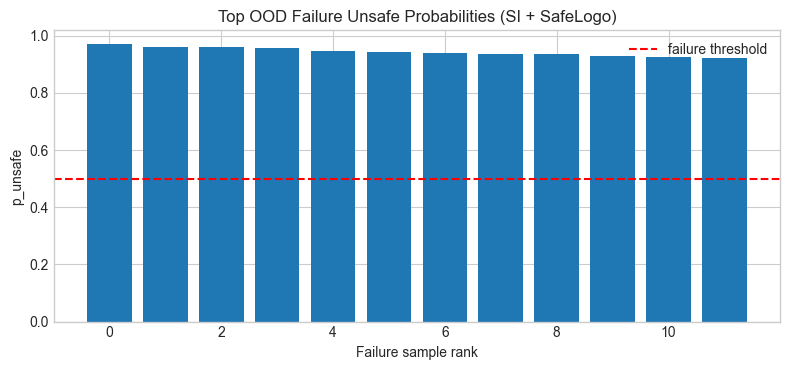

In [15]:

def per_sample_max_unsafe(x, delta, mask, table, families, safety_on=True):
    sb = DEFAULT_SAFETY_BIAS if safety_on else 0.0
    probs = []
    for fam in families:
        a = attack_strength(x, fam, table)
        z = unsafe_logit(x, a, delta, mask, sb)
        probs.append(sigmoid(z))
    probs = np.stack(probs, axis=1)
    idx = np.argmax(probs, axis=1)
    pmax = probs[np.arange(len(x)), idx]
    fam = [families[i] for i in idx]
    return pmax, fam

p_si, fam_si = per_sample_max_unsafe(X_h_ood, zero_delta, mask_ref, ATTACK_OOD, ['PAIR', 'GCG', 'PAP', 'AutoDAN'], safety_on=True)
p_silogo, fam_silogo = per_sample_max_unsafe(X_h_ood, si_logo_delta, mask_ref, ATTACK_OOD, ['PAIR', 'GCG', 'PAP', 'AutoDAN'], safety_on=True)

fail_idx = np.where(p_silogo > 0.5)[0]

rows = []
for i in fail_idx:
    rows.append((int(i), fam_silogo[i], float(p_silogo[i]), float(p_si[i] - p_silogo[i])))

rows = sorted(rows, key=lambda x: x[2], reverse=True)[:12]

print('Top failure samples (index, strongest_attack, p_unsafe_with_logo, gain_vs_SI_only):')
for r in rows:
    print(r)

if rows:
    vals = [r[2] for r in rows]
    plt.figure(figsize=(8,3.8))
    plt.bar(np.arange(len(vals)), vals)
    plt.axhline(0.5, color='r', linestyle='--', label='failure threshold')
    plt.title('Top OOD Failure Unsafe Probabilities (SI + SafeLogo)')
    plt.xlabel('Failure sample rank')
    plt.ylabel('p_unsafe')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No OOD failures under current threshold (>0.5).')



## 7) 与论文原始设定对齐与差异

### 对齐点
- 使用了论文核心双层机制：inner 选最强攻击，outer 更新局部 logo。
- 使用了同类核心控制量：`defense weight`、`coverage ratio`、`epsilon`。
- 指标结构与论文一致方向：防御有效性（ASR）+ benign utility + OOD 泛化 + 消融。

### 差异点（必须明确）
1. 本 notebook 使用 surrogate VLM 环境，而非真实 LLaVA/Qwen/Gemini 推理链。
2. 未复现论文中真实数据集（MM-SafetyBench/MM-Vet/VLGuard/MME）的原始样本与打分器。
3. 未调用 LLM-as-Judge API，而使用可微代理危害分数近似。

### 为什么仍有价值
- 能在低成本环境里验证 SafeLogo 的因果机制和参数趋势。
- 能快速做假设检验：哪些参数更影响鲁棒性/可用性 trade-off。
- 可作为后续真实 VLM 复现前的实验脚手架。


In [16]:

# Final compact report artifact
report = {
    'main_results': main_results,
    'ablation_weight': abl_weight,
    'ablation_coverage': abl_cov,
    'ablation_epsilon': abl_eps,
    'noise_robustness': {
        'noise_grid': noise_grid,
        'si_only_asr': noise_res_si,
        'si_logo_asr': noise_res_silogo,
    },
    'ood_asr': {
        'si_only': ood_si,
        'si_logo': ood_silogo,
    },
    'lr_sensitivity': {
        'lr_grid': lr_grid,
        'asr': lr_asr,
        'benign_retention': lr_ben,
    }
}

out_json = '/Users/peiduo/Desktop/aidev/SafeLogo_paper/safelogo_repro_report.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print('Saved report:', out_json)


Saved report: /Users/peiduo/Desktop/aidev/SafeLogo_paper/safelogo_repro_report.json
